In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Task 8
part 1
Task 1.1

In [2]:
train_df = pd.read_parquet("dataset/raw/train.parquet")
eval_df = pd.read_csv("dataset/raw/eval.csv")

In [3]:
train_df.head()
train_df.info()
train_df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 4500000 entries, 0 to 4499999
Data columns (total 19 columns):
 #   Column               Dtype  
---  ------               -----  
 0   city_id              int64  
 1   store_id             int64  
 2   management_group_id  int64  
 3   first_category_id    int64  
 4   second_category_id   int64  
 5   third_category_id    int64  
 6   product_id           int64  
 7   dt                   str    
 8   sale_amount          float64
 9   hours_sale           object 
 10  stock_hour6_22_cnt   int32  
 11  hours_stock_status   object 
 12  discount             float64
 13  holiday_flag         int32  
 14  activity_flag        int32  
 15  precpt               float64
 16  avg_temperature      float64
 17  avg_humidity         float64
 18  avg_wind_level       float64
dtypes: float64(6), int32(3), int64(7), object(2), str(1)
memory usage: 643.7+ MB


,city_id,store_id,management_group_id,first_category_id,second_category_id,third_category_id,product_id,sale_amount,stock_hour6_22_cnt,discount,holiday_flag,activity_flag,precpt,avg_temperature,avg_humidity,avg_wind_level
count,4.500000e+06,4.500000e+06,4.500000e+06,4.500000e+06,4.500000e+06,4.500000e+06,4.500000e+06,4.500000e+06,4.500000e+06,4.500000e+06,4.500000e+06,4.500000e+06,4.500000e+06,4.500000e+06,4.500000e+06,4.500000e+06
mean,4.974420e+00,4.090807e+02,4.621640e+00,1.521366e+01,4.473508e+01,1.163621e+02,3.904260e+02,9.985913e-01,3.180341e+00,9.111412e-01,3.444444e-01,3.784207e-01,3.698385e+00,2.227911e+01,7.445046e+01,1.724542e+00
std,6.096600e+00,2.485456e+02,1.962418e+00,8.972127e+00,2.233890e+01,5.756037e+01,2.634697e+02,1.406738e+00,4.596586e+00,1.281734e-01,4.751868e-01,4.849933e-01,3.683960e+00,3.593264e+00,1.009831e+01,3.845731e-01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.206000e+01,2.735000e+01,9.700000e-01
25%,0.000000e+00,1.950000e+02,3.000000e+00,5.000000e+00,2.800000e+01,7.700000e+01,1.350000e+02,4.000000e-01,0.000000e+00,8.510000e-01,0.000000e+00,0.000000e+00,1.428800e+00,1.939000e+01,7.162000e+01,1.450000e+00
50%,0.000000e+00,3.950000e+02,6.000000e+00,1.600000e+01,3.800000e+01,1.110000e+02,3.630000e+02,7.000000e-01,0.000000e+00,9.890000e-01,0.000000e+00,0.000000e+00,2.297700e+00,2.250000e+01,7.636000e+01,1.640000e+00
75%,1.200000e+01,5.980000e+02,6.000000e+00,2.100000e+01,6.600000e+01,1.670000e+02,6.330000e+02,1.100000e+00,6.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,4.481600e+00,2.540000e+01,8.071000e+01,1.950000e+00
max,1.700000e+01,8.970000e+02,6.000000e+00,3.100000e+01,8.300000e+01,2.320000e+02,8.640000e+02,4.490000e+01,1.600000e+01,1.088000e+00,1.000000e+00,1.000000e+00,4.250000e+01,3.088000e+01,1.000000e+02,3.850000e+00


In [4]:
train_df.isnull().sum()

city_id                0
store_id               0
management_group_id    0
first_category_id      0
second_category_id     0
third_category_id      0
product_id             0
dt                     0
sale_amount            0
hours_sale             0
stock_hour6_22_cnt     0
hours_stock_status     0
discount               0
holiday_flag           0
activity_flag          0
precpt                 0
avg_temperature        0
avg_humidity           0
avg_wind_level         0
dtype: int64

In [5]:
train_df["store_id"].nunique()

898

In [6]:
train_df["product_id"].nunique()

865

In [7]:
train_df["dt"] = pd.to_datetime(train_df["dt"])
train_df["dt"].min(), train_df["dt"].max()

(Timestamp('2024-03-28 00:00:00'), Timestamp('2024-06-25 00:00:00'))

In [8]:
train_df.shape
eval_df.shape

(350000, 19)

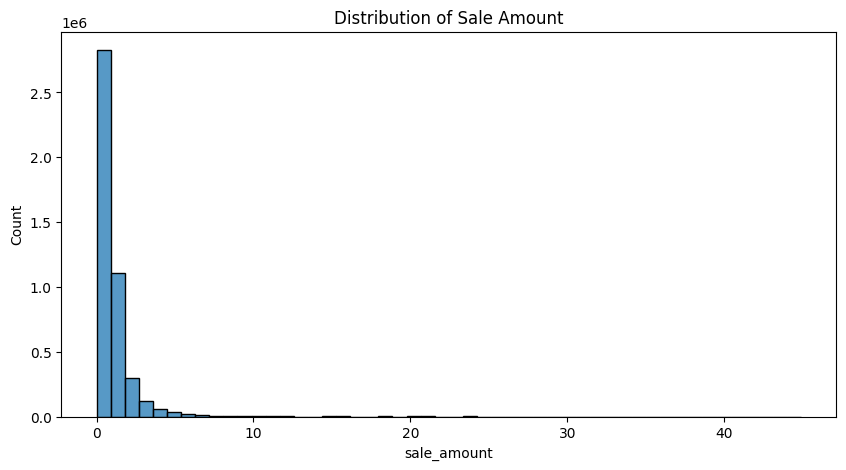

In [9]:
plt.figure(figsize=(10,5))
sns.histplot(train_df["sale_amount"], bins=50)
plt.title("Distribution of Sale Amount")
plt.show()

In [10]:
mean_val = train_df["sale_amount"].mean()
median_val = train_df["sale_amount"].median()
std_val = train_df["sale_amount"].std()
skew_val = train_df["sale_amount"].skew()

mean_val, median_val, std_val, skew_val

(np.float64(0.9985912860000001),
 np.float64(0.7),
 np.float64(1.4067375825269162),
 np.float64(8.471775179820984))

In [11]:
zero_sales_ratio = (train_df["sale_amount"] == 0).mean()
zero_sales_ratio * 100 # percentage of zero sales

np.float64(4.461333333333333)

Եթե zero proportion-ը մեծ է (օրինակ 50%+), սա նշանակում է 
Model-ը պետք է սովորի երկու բան՝
    երբ վաճառք կլինի,
    որքան կլինի վաճառքը:
Mean-ը դառնում է misleading

Task 1.2


In [12]:
train_df["dt"] = pd.to_datetime(
    train_df["dt"],
    errors="coerce"
)

In [13]:
train_df["day_of_week"] = train_df["dt"].dt.day_name()
train_df["day_of_week"].value_counts()

day_of_week
Thursday     650000
Friday       650000
Saturday     650000
Sunday       650000
Monday       650000
Tuesday      650000
Wednesday    600000
Name: count, dtype: int64

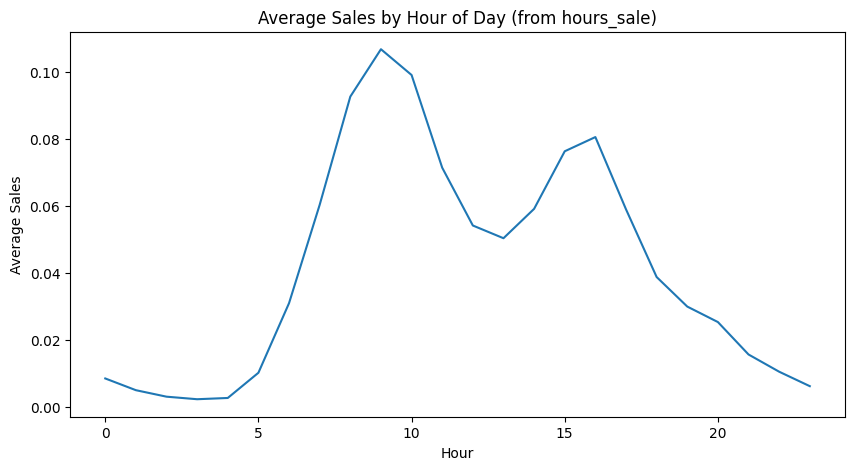

In [ ]:
# compute mean sale per hour from the hours_sale lists
hourly_sales = pd.DataFrame(train_df["hours_sale"].tolist()).mean(axis=0)
hourly_sales.index = range(len(hourly_sales)) 
plt.figure(figsize=(10,5))
hourly_sales.plot()
plt.title("Average Sales by Hour of Day (from hours_sale)")
plt.xlabel("Hour")
plt.ylabel("Average Sales")
plt.show()

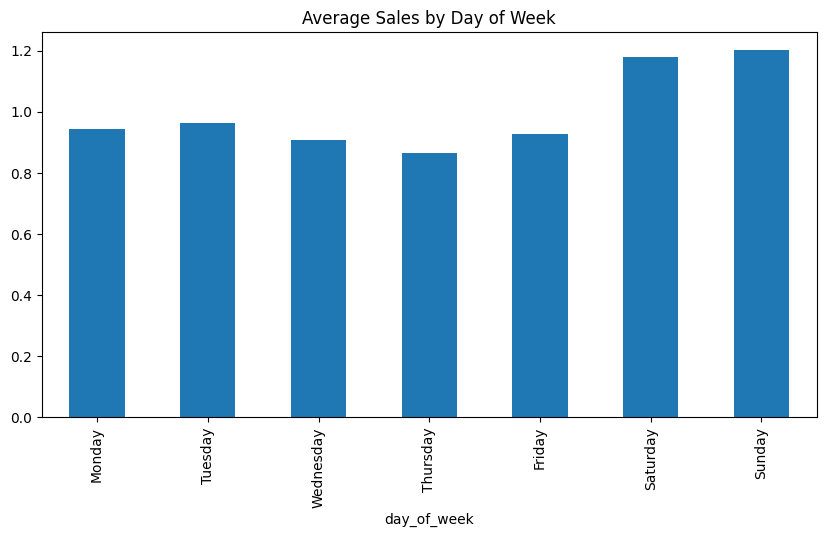

In [14]:
weekly_sales = train_df.groupby("day_of_week")["sale_amount"].mean()
weekly_sales = weekly_sales.reindex(
    ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
)
plt.figure(figsize=(10,5))
weekly_sales.plot(kind="bar")
plt.title("Average Sales by Day of Week")
plt.show()


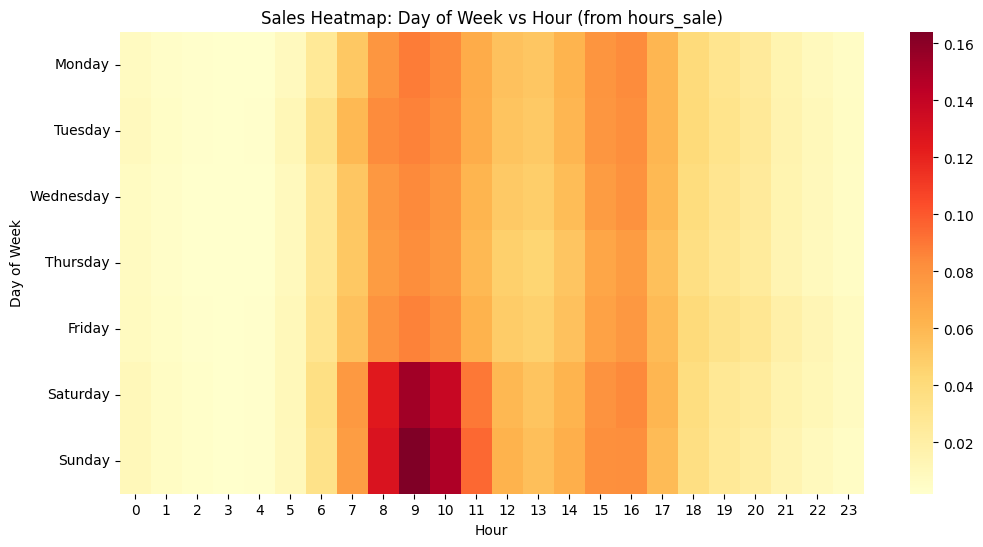

In [15]:
hours_df = pd.DataFrame(train_df["hours_sale"].tolist(), columns=range(24))
hours_df["day_of_week"] = train_df["day_of_week"].values

heatmap_data = hours_df.groupby("day_of_week").mean().reindex(
    ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
)

plt.figure(figsize=(12,6))
sns.heatmap(heatmap_data, cmap="YlOrRd")
plt.title("Sales Heatmap: Day of Week vs Hour (from hours_sale)")
plt.ylabel("Day of Week")
plt.xlabel("Hour")
plt.show()


In [16]:
type(train_df["hours_stock_status"].iloc[0])
train_df["stockout_rate"] = train_df["hours_stock_status"].apply(
    lambda x: np.mean(x)
    if isinstance(x, (list, np.ndarray)) and len(x) > 0
    else np.nan
)
train_df["stockout_rate"].describe()

count    4.500000e+06
mean     2.488556e-01
std      2.807814e-01
min      0.000000e+00
25%      0.000000e+00
50%      1.666667e-01
75%      4.166667e-01
max      1.000000e+00
Name: stockout_rate, dtype: float64

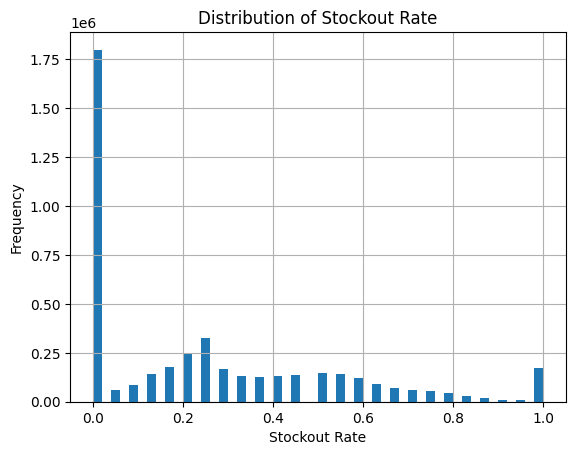

In [18]:
train_df["stockout_rate"].hist(bins=50)
plt.title("Distribution of Stockout Rate")
plt.xlabel("Stockout Rate")
plt.ylabel("Frequency")
plt.show()



In [20]:
train_df["hours_stock_status"] = pd.to_numeric(
    train_df["hours_stock_status"],
    errors="coerce"
)
train_df["hours_stock_status"]



0         NaN
1         NaN
2         NaN
3         NaN
4         NaN
           ..
4499995   NaN
4499996   NaN
4499997   NaN
4499998   NaN
4499999   NaN
Name: hours_stock_status, Length: 4500000, dtype: float64

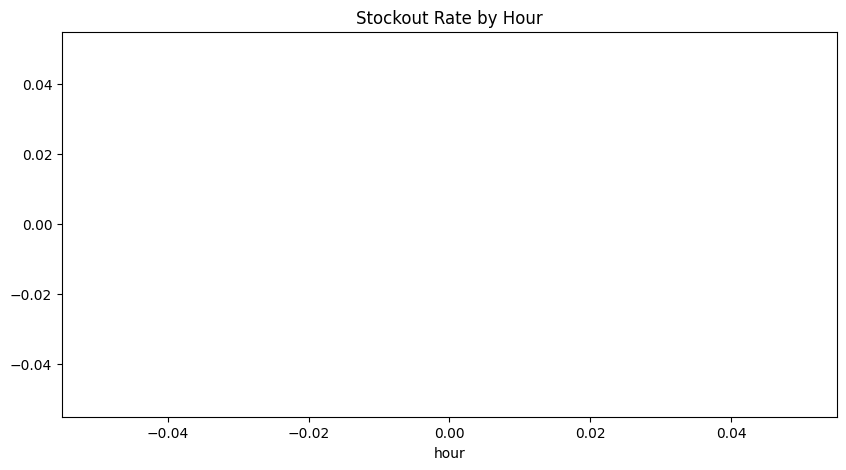

In [ ]:
stockout_by_hour = train_df.groupby("hour")["hours_stock_status"].mean()

plt.figure(figsize=(10,5))
stockout_by_hour.plot()
plt.title("Stockout Rate by Hour")
plt.show()